# 05 -- Robustness & Hyperparameter Sensitivity

Sensitivity of the winning topology from Notebook 04 to: basis size,
regularisation strengths, estimator mode, endpoint method, and diffusion
estimation mode.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from chromlearn import find_repo_root

ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from chromlearn.io.catalog import load_condition
from chromlearn.io.trajectory import trim_trajectory
from chromlearn.model_fitting import FitConfig
from chromlearn.model_fitting.basis import BSplineBasis
from chromlearn.model_fitting.diffusion import local_diffusion_estimates
from chromlearn.model_fitting.features import build_design_matrix
from chromlearn.model_fitting.fit import CVResult, cross_validate, fit_kernels, fit_model
from chromlearn.model_fitting.plotting import plot_cv_curve, plot_kernels

plt.rcParams["figure.dpi"] = 110

## Setup

In [2]:
# Update this after consulting Notebook 04 results.
WINNING_TOPOLOGY = "poles"

CONDITION = "rpe18_ctr"
cells_raw = load_condition(CONDITION)
cells = [trim_trajectory(c, method="neb_ao_frac") for c in cells_raw]
print(f"Loaded {len(cells)} rpe18_ctr cells (trimmed to neb_ao_frac=0.5 window).")

BASE_CONFIG = FitConfig(
    topology=WINNING_TOPOLOGY,
    n_basis_xx=10,
    n_basis_xy=10,
    lambda_ridge=1e-3,
    lambda_rough=1e-3,
    basis_eval_mode="ito",
    endpoint_method="neb_ao_frac",
    diffusion_mode="msd",
    dt=5.0,
)

Loaded 13 rpe18_ctr cells (trimmed to neb_ao_frac=0.5 window).


## Sweep 1: Basis size

Joint sweep of `n_basis` for xx and xy kernels.

In [3]:
N_BASIS_VALUES = [4, 6, 8, 10, 12, 16, 20]

cv_basis: dict[str, CVResult] = {}
for n in N_BASIS_VALUES:
    cfg = FitConfig(
        topology=BASE_CONFIG.topology,
        n_basis_xx=n,
        n_basis_xy=n,
        r_min_xx=BASE_CONFIG.r_min_xx,
        r_max_xx=BASE_CONFIG.r_max_xx,
        r_min_xy=BASE_CONFIG.r_min_xy,
        r_max_xy=BASE_CONFIG.r_max_xy,
        basis_type=BASE_CONFIG.basis_type,
        lambda_ridge=BASE_CONFIG.lambda_ridge,
        lambda_rough=BASE_CONFIG.lambda_rough,
        basis_eval_mode=BASE_CONFIG.basis_eval_mode,
        endpoint_method=BASE_CONFIG.endpoint_method,
        diffusion_mode=BASE_CONFIG.diffusion_mode,
        dt=BASE_CONFIG.dt,
    )
    cv_basis[str(n)] = cross_validate(cells, cfg)
    print(
        f"  n_basis={n:3d}  CV = {cv_basis[str(n)].mean_error:.4e}"
        f" ± {cv_basis[str(n)].fold_se:.4e}"
    )

  n_basis=  4  CV = 7.7350e-04 ± 6.1000e-05


  n_basis=  6  CV = 7.7354e-04 ± 6.0994e-05


  n_basis=  8  CV = 7.7352e-04 ± 6.1010e-05


  n_basis= 10  CV = 7.7353e-04 ± 6.1010e-05


  n_basis= 12  CV = 7.7355e-04 ± 6.1015e-05


  n_basis= 16  CV = 7.7356e-04 ± 6.1019e-05


  n_basis= 20  CV = 7.7356e-04 ± 6.1022e-05


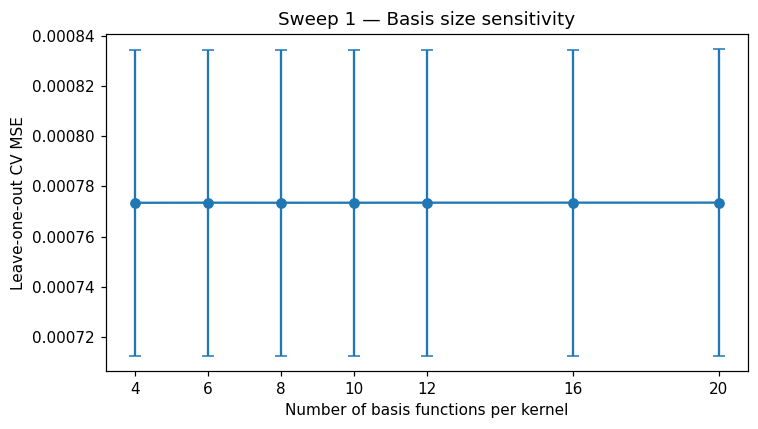


Best n_basis: 4  (CV MSE = 7.7350e-04)


In [4]:
fig_basis, ax_basis = plt.subplots(figsize=(7, 4))
n_vals = [int(k) for k in cv_basis]
means = [cv_basis[k].mean_error for k in cv_basis]
stds = [cv_basis[k].fold_se for k in cv_basis]
ax_basis.errorbar(n_vals, means, yerr=stds, fmt="o-", capsize=4, color="C0")
ax_basis.set_xlabel("Number of basis functions per kernel")
ax_basis.set_ylabel("Leave-one-out CV MSE")
ax_basis.set_title("Sweep 1 — Basis size sensitivity")
ax_basis.set_xticks(n_vals)
fig_basis.tight_layout()
plt.show()

best_n_basis = int(min(cv_basis, key=lambda k: cv_basis[k].mean_error))
print(f"\nBest n_basis: {best_n_basis}  (CV MSE = {cv_basis[str(best_n_basis)].mean_error:.4e})")

## Sweep 2: Regularisation

Sub-sweep ridge (fix roughness) then roughness (fix ridge).

In [5]:
LAMBDA_GRID = np.logspace(-6, 1, 20)
FIXED_RIDGE = 1e-3
FIXED_ROUGH = 1e-3

cv_ridge: dict[str, CVResult] = {}
for lam in LAMBDA_GRID:
    cfg = FitConfig(
        topology=BASE_CONFIG.topology,
        n_basis_xx=BASE_CONFIG.n_basis_xx,
        n_basis_xy=BASE_CONFIG.n_basis_xy,
        r_min_xx=BASE_CONFIG.r_min_xx,
        r_max_xx=BASE_CONFIG.r_max_xx,
        r_min_xy=BASE_CONFIG.r_min_xy,
        r_max_xy=BASE_CONFIG.r_max_xy,
        basis_type=BASE_CONFIG.basis_type,
        lambda_ridge=lam,
        lambda_rough=FIXED_ROUGH,
        basis_eval_mode=BASE_CONFIG.basis_eval_mode,
        endpoint_method=BASE_CONFIG.endpoint_method,
        diffusion_mode=BASE_CONFIG.diffusion_mode,
        dt=BASE_CONFIG.dt,
    )
    key = f"{lam:.2e}"
    cv_ridge[key] = cross_validate(cells, cfg)

cv_rough: dict[str, CVResult] = {}
for lam in LAMBDA_GRID:
    cfg = FitConfig(
        topology=BASE_CONFIG.topology,
        n_basis_xx=BASE_CONFIG.n_basis_xx,
        n_basis_xy=BASE_CONFIG.n_basis_xy,
        r_min_xx=BASE_CONFIG.r_min_xx,
        r_max_xx=BASE_CONFIG.r_max_xx,
        r_min_xy=BASE_CONFIG.r_min_xy,
        r_max_xy=BASE_CONFIG.r_max_xy,
        basis_type=BASE_CONFIG.basis_type,
        lambda_ridge=FIXED_RIDGE,
        lambda_rough=lam,
        basis_eval_mode=BASE_CONFIG.basis_eval_mode,
        endpoint_method=BASE_CONFIG.endpoint_method,
        diffusion_mode=BASE_CONFIG.diffusion_mode,
        dt=BASE_CONFIG.dt,
    )
    key = f"{lam:.2e}"
    cv_rough[key] = cross_validate(cells, cfg)

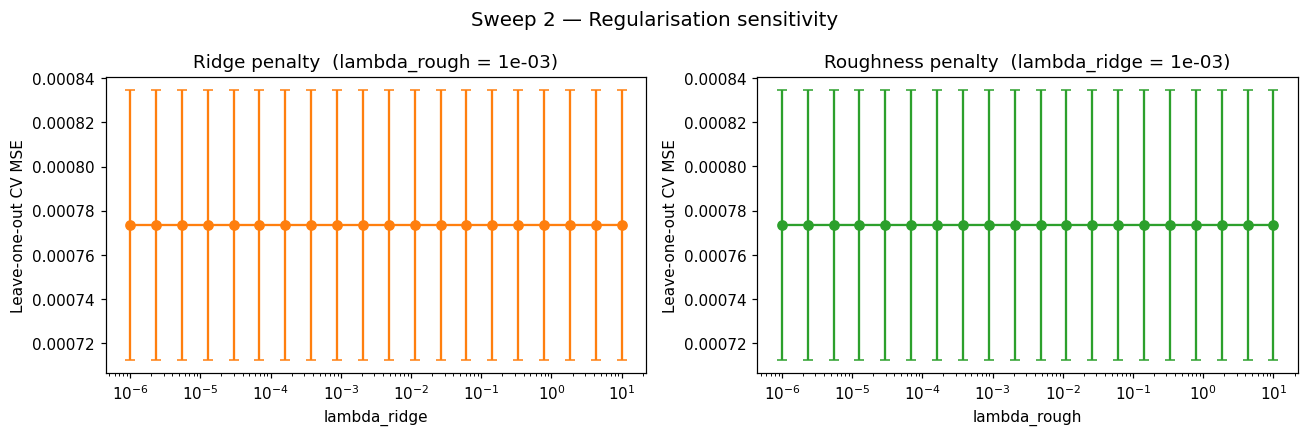

Best lambda_ridge: 1.13e-02  (CV MSE = 7.7353e-04)
Best lambda_rough: 1.13e-02  (CV MSE = 7.7353e-04)


In [6]:
fig_reg, axes_reg = plt.subplots(1, 2, figsize=(12, 4))

ridge_lams = LAMBDA_GRID
ridge_means = [cv_ridge[f"{l:.2e}"].mean_error for l in ridge_lams]
ridge_stds = [cv_ridge[f"{l:.2e}"].fold_se for l in ridge_lams]
axes_reg[0].errorbar(ridge_lams, ridge_means, yerr=ridge_stds, fmt="o-", capsize=3, color="C1")
axes_reg[0].set_xscale("log")
axes_reg[0].set_xlabel("lambda_ridge")
axes_reg[0].set_ylabel("Leave-one-out CV MSE")
axes_reg[0].set_title(f"Ridge penalty  (lambda_rough = {FIXED_ROUGH:.0e})")

rough_lams = LAMBDA_GRID
rough_means = [cv_rough[f"{l:.2e}"].mean_error for l in rough_lams]
rough_stds = [cv_rough[f"{l:.2e}"].fold_se for l in rough_lams]
axes_reg[1].errorbar(rough_lams, rough_means, yerr=rough_stds, fmt="o-", capsize=3, color="C2")
axes_reg[1].set_xscale("log")
axes_reg[1].set_xlabel("lambda_rough")
axes_reg[1].set_ylabel("Leave-one-out CV MSE")
axes_reg[1].set_title(f"Roughness penalty  (lambda_ridge = {FIXED_RIDGE:.0e})")

fig_reg.suptitle("Sweep 2 — Regularisation sensitivity", fontsize=13)
fig_reg.tight_layout()
plt.show()

best_ridge = float(ridge_lams[int(np.argmin(ridge_means))])
best_rough = float(rough_lams[int(np.argmin(rough_means))])
print(f"Best lambda_ridge: {best_ridge:.2e}  (CV MSE = {min(ridge_means):.4e})")
print(f"Best lambda_rough: {best_rough:.2e}  (CV MSE = {min(rough_means):.4e})")

## Sweep 3: Estimator mode (Ito / Ito-shift / Stratonovich)

"ito" = current positions, "ito_shift" = previous positions (decorrelates
localisation noise), "strato" = midpoint (Stratonovich convention).

In [7]:
ESTIMATOR_MODES = ["ito", "ito_shift", "strato"]

cv_mode: dict[str, CVResult] = {}
models_mode: dict[str, object] = {}

for mode in ESTIMATOR_MODES:
    cfg = FitConfig(
        topology=BASE_CONFIG.topology,
        n_basis_xx=BASE_CONFIG.n_basis_xx,
        n_basis_xy=BASE_CONFIG.n_basis_xy,
        r_min_xx=BASE_CONFIG.r_min_xx,
        r_max_xx=BASE_CONFIG.r_max_xx,
        r_min_xy=BASE_CONFIG.r_min_xy,
        r_max_xy=BASE_CONFIG.r_max_xy,
        basis_type=BASE_CONFIG.basis_type,
        lambda_ridge=BASE_CONFIG.lambda_ridge,
        lambda_rough=BASE_CONFIG.lambda_rough,
        basis_eval_mode=mode,
        endpoint_method=BASE_CONFIG.endpoint_method,
        diffusion_mode=BASE_CONFIG.diffusion_mode,
        dt=BASE_CONFIG.dt,
    )
    cv_mode[mode] = cross_validate(cells, cfg)
    models_mode[mode] = fit_model(cells, cfg)
    print(
        f"  mode={mode:12s}  CV = {cv_mode[mode].mean_error:.4e}"
        f" ± {cv_mode[mode].fold_se:.4e}"
    )

  mode=ito           CV = 7.7353e-04 ± 6.1010e-05


  mode=ito_shift     CV = 7.7018e-04 ± 6.0721e-05


  mode=strato        CV = 7.7793e-04 ± 6.1269e-05


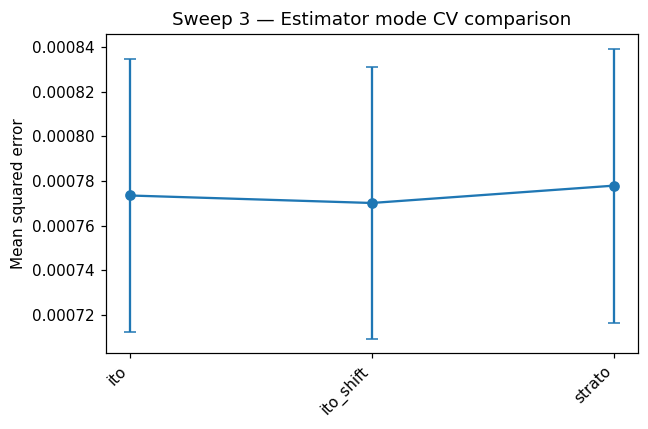

In [8]:
fig_mode_cv = plot_cv_curve(cv_mode)
fig_mode_cv.axes[0].set_title("Sweep 3 — Estimator mode CV comparison")
plt.show()

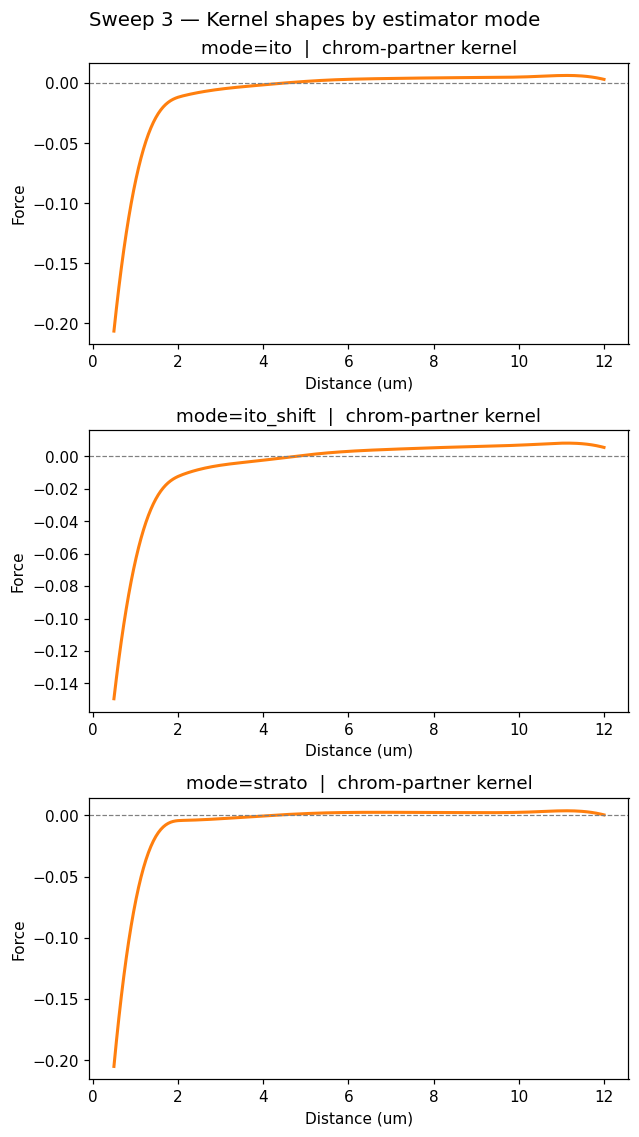


Best estimator mode: ito_shift  (CV MSE = 7.7018e-04)


In [9]:
# Kernel shapes for each mode side by side
from chromlearn.model_fitting.model import FittedModel  # noqa: E402

topology_has_chroms = WINNING_TOPOLOGY in ("poles_and_chroms", "center_and_chroms")
n_panels_per_model = 2 if topology_has_chroms else 1
n_modes = len(ESTIMATOR_MODES)

fig_mode_kernels, axes_mode_k = plt.subplots(
    n_modes,
    n_panels_per_model,
    figsize=(6 * n_panels_per_model, 3.5 * n_modes),
    squeeze=False,
)

for row, mode in enumerate(ESTIMATOR_MODES):
    model: FittedModel = models_mode[mode]
    n_points = 200

    if topology_has_chroms:
        r_xx = np.linspace(model.basis_xx.r_min, model.basis_xx.r_max, n_points)
        phi_xx = model.basis_xx.evaluate(r_xx)
        axes_mode_k[row, 0].plot(r_xx, phi_xx @ model.theta_xx, color="C0", linewidth=2)
        axes_mode_k[row, 0].axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
        axes_mode_k[row, 0].set_xlabel("Distance (um)")
        axes_mode_k[row, 0].set_ylabel("Force")
        axes_mode_k[row, 0].set_title(f"mode={mode}  |  chrom-chrom kernel")

    r_xy = np.linspace(model.basis_xy.r_min, model.basis_xy.r_max, n_points)
    phi_xy = model.basis_xy.evaluate(r_xy)
    col_xy = n_panels_per_model - 1
    axes_mode_k[row, col_xy].plot(r_xy, phi_xy @ model.theta_xy, color="C1", linewidth=2)
    axes_mode_k[row, col_xy].axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    axes_mode_k[row, col_xy].set_xlabel("Distance (um)")
    axes_mode_k[row, col_xy].set_ylabel("Force")
    axes_mode_k[row, col_xy].set_title(f"mode={mode}  |  chrom-partner kernel")

fig_mode_kernels.suptitle("Sweep 3 — Kernel shapes by estimator mode", fontsize=13)
fig_mode_kernels.tight_layout()
plt.show()

best_mode = min(cv_mode, key=lambda k: cv_mode[k].mean_error)
print(f"\nBest estimator mode: {best_mode}  (CV MSE = {cv_mode[best_mode].mean_error:.4e})")

## Sweep 4: Endpoint fraction

Sweep the NEB-to-AO fraction (0.33 to 1.0) and also try end_sep (95% plateau).

In [10]:
ENDPOINT_FRACS = [0.33, 0.5, 0.67, 0.8, 1.0]

raw_cells = cells_raw
print(f"Using {len(raw_cells)} raw CellData objects for endpoint sweep.")

Using 13 raw CellData objects for endpoint sweep.


In [11]:
cv_endpoint: dict[str, CVResult] = {}
n_cells_endpoint: dict[str, int] = {}

# Sweep neb_ao_frac values
for frac in ENDPOINT_FRACS:
    label = f"frac={frac:.2f}"
    trimmed_method = []
    for raw_cell in raw_cells:
        try:
            trimmed_method.append(trim_trajectory(raw_cell, method="neb_ao_frac", frac=frac))
        except ValueError as exc:
            print(f"  Skipping {raw_cell.cell_id} for {label}: {exc}")

    n_cells_endpoint[label] = len(trimmed_method)
    if len(trimmed_method) < 3:
        print(f"  {label}: only {len(trimmed_method)} cells — skipping CV (too few).")
        continue

    cfg = FitConfig(
        topology=BASE_CONFIG.topology,
        n_basis_xx=BASE_CONFIG.n_basis_xx,
        n_basis_xy=BASE_CONFIG.n_basis_xy,
        r_min_xx=BASE_CONFIG.r_min_xx,
        r_max_xx=BASE_CONFIG.r_max_xx,
        r_min_xy=BASE_CONFIG.r_min_xy,
        r_max_xy=BASE_CONFIG.r_max_xy,
        basis_type=BASE_CONFIG.basis_type,
        lambda_ridge=BASE_CONFIG.lambda_ridge,
        lambda_rough=BASE_CONFIG.lambda_rough,
        basis_eval_mode=BASE_CONFIG.basis_eval_mode,
        endpoint_method="neb_ao_frac",
        endpoint_frac=frac,
        diffusion_mode=BASE_CONFIG.diffusion_mode,
        dt=BASE_CONFIG.dt,
    )
    cv_endpoint[label] = cross_validate(trimmed_method, cfg)
    print(
        f"  {label}  n_cells={len(trimmed_method)}"
        f"  CV = {cv_endpoint[label].mean_error:.4e}"
        f" +/- {cv_endpoint[label].fold_se:.4e}"
    )

# Also try end_sep
trimmed_end_sep = []
for raw_cell in raw_cells:
    try:
        trimmed_end_sep.append(trim_trajectory(raw_cell, method="end_sep"))
    except ValueError as exc:
        print(f"  Skipping {raw_cell.cell_id} for end_sep: {exc}")

n_cells_endpoint["end_sep"] = len(trimmed_end_sep)
if len(trimmed_end_sep) >= 3:
    cfg_es = FitConfig(
        topology=BASE_CONFIG.topology,
        n_basis_xx=BASE_CONFIG.n_basis_xx,
        n_basis_xy=BASE_CONFIG.n_basis_xy,
        r_min_xx=BASE_CONFIG.r_min_xx,
        r_max_xx=BASE_CONFIG.r_max_xx,
        r_min_xy=BASE_CONFIG.r_min_xy,
        r_max_xy=BASE_CONFIG.r_max_xy,
        basis_type=BASE_CONFIG.basis_type,
        lambda_ridge=BASE_CONFIG.lambda_ridge,
        lambda_rough=BASE_CONFIG.lambda_rough,
        basis_eval_mode=BASE_CONFIG.basis_eval_mode,
        endpoint_method="end_sep",
        diffusion_mode=BASE_CONFIG.diffusion_mode,
        dt=BASE_CONFIG.dt,
    )
    cv_endpoint["end_sep"] = cross_validate(trimmed_end_sep, cfg_es)
    print(
        f"  end_sep  n_cells={len(trimmed_end_sep)}"
        f"  CV = {cv_endpoint['end_sep'].mean_error:.4e}"
        f" +/- {cv_endpoint['end_sep'].fold_se:.4e}"
    )
else:
    print(f"  end_sep: only {len(trimmed_end_sep)} cells — skipping CV (too few).")

  Skipping rpe18_ctr_006 for frac=0.33: rpe18_ctr_006: trimmed trajectory has 70 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_032 for frac=0.33: rpe18_ctr_032: trimmed trajectory has 77 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_034 for frac=0.33: rpe18_ctr_034: trimmed trajectory has 76 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_035 for frac=0.33: rpe18_ctr_035: trimmed trajectory has 79 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_043 for frac=0.33: rpe18_ctr_043: trimmed trajectory has 79 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_049 for frac=0.33: rpe18_ctr_049: trimmed trajectory has 68 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_501 for frac=0.33: rpe18_ctr_501: trimmed trajectory has 89 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_502 for frac=0.33: rpe18_ctr_502: trimmed trajectory has 92 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_505 for frac=0.33: rpe18_ctr_505: trimmed t

  frac=0.33  n_cells=3  CV = 8.8510e-04 +/- 9.2849e-05


  frac=0.50  n_cells=13  CV = 7.7353e-04 +/- 6.1010e-05


  frac=0.67  n_cells=13  CV = 7.5356e-04 +/- 5.8253e-05


  frac=0.80  n_cells=13  CV = 7.4990e-04 +/- 5.6744e-05


  frac=1.00  n_cells=13  CV = 7.2911e-04 +/- 5.3586e-05
  Skipping rpe18_ctr_034 for end_sep: rpe18_ctr_034: trimmed trajectory has 96 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_035 for end_sep: rpe18_ctr_035: trimmed trajectory has 75 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_043 for end_sep: rpe18_ctr_043: trimmed trajectory has 84 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_049 for end_sep: rpe18_ctr_049: trimmed trajectory has 73 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_500 for end_sep: rpe18_ctr_500: trimmed trajectory has 89 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_501 for end_sep: rpe18_ctr_501: trimmed trajectory has 77 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_502 for end_sep: rpe18_ctr_502: trimmed trajectory has 74 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_505 for end_sep: rpe18_ctr_505: trimmed trajectory has 76 frames, fewer than the minimum 100.
  Skipping rpe18_ctr_506

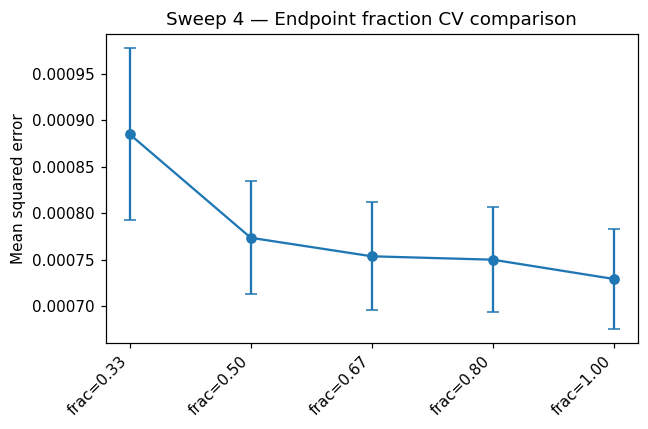


Best endpoint: frac=1.00  (CV MSE = 7.2911e-04)

Cell counts per endpoint setting:
  frac=0.33           : 3 cells
  frac=0.50           : 13 cells
  frac=0.67           : 13 cells
  frac=0.80           : 13 cells
  frac=1.00           : 13 cells
  end_sep             : 2 cells


In [12]:
if cv_endpoint:
    fig_ep = plot_cv_curve(cv_endpoint)
    fig_ep.axes[0].set_title("Sweep 4 — Endpoint fraction CV comparison")
    plt.show()

    best_endpoint = min(cv_endpoint, key=lambda k: cv_endpoint[k].mean_error)
    print(f"\nBest endpoint: {best_endpoint}  (CV MSE = {cv_endpoint[best_endpoint].mean_error:.4e})")
else:
    print("No endpoint settings produced enough cells for CV.")

print("\nCell counts per endpoint setting:")
for label in list(f"frac={f:.2f}" for f in ENDPOINT_FRACS) + ["end_sep"]:
    print(f"  {label:20s}: {n_cells_endpoint.get(label, 0)} cells")

## Sweep 5: Diffusion estimation mode

Compare scalar D across four estimators (msd, vestergaard, weak_noise,
f_corrected).

In [13]:
from chromlearn.model_fitting.basis import BSplineBasis as _BSplineBasis, HatBasis  # noqa: E402

_BasisClass = _BSplineBasis if BASE_CONFIG.basis_type == "bspline" else HatBasis

_topology_has_chroms = WINNING_TOPOLOGY in ("poles_and_chroms", "center_and_chroms")
if _topology_has_chroms:
    _basis_xx_fc = _BasisClass(
        BASE_CONFIG.r_min_xx, BASE_CONFIG.r_max_xx, BASE_CONFIG.n_basis_xx
    )
else:
    _basis_xx_fc = None

_basis_xy_fc = _BasisClass(
    BASE_CONFIG.r_min_xy, BASE_CONFIG.r_max_xy, BASE_CONFIG.n_basis_xy
)

from scipy.linalg import block_diag  # noqa: E402

_R_xx = _basis_xx_fc.roughness_matrix() if _basis_xx_fc is not None else None
_R_xy = _basis_xy_fc.roughness_matrix()
_roughness_fc = block_diag(_R_xx, _R_xy) if _R_xx is not None else _R_xy

_G_fc, _V_fc = build_design_matrix(
    cells,
    _basis_xx_fc,
    _basis_xy_fc,
    basis_eval_mode=BASE_CONFIG.basis_eval_mode,
    topology=WINNING_TOPOLOGY,
)
_fit_result_fc = fit_kernels(
    _G_fc,
    _V_fc,
    lambda_ridge=BASE_CONFIG.lambda_ridge,
    lambda_rough=BASE_CONFIG.lambda_rough,
    R=_roughness_fc,
)

print("Preliminary fit for f_corrected mode complete.")
print(f"  theta shape: {_fit_result_fc.theta.shape}")
print(f"  residuals shape: {_fit_result_fc.residuals.shape}")

Preliminary fit for f_corrected mode complete.
  theta shape: (10,)
  residuals shape: (229776,)


In [14]:
DIFFUSION_MODES = ["msd", "vestergaard", "weak_noise", "f_corrected"]

D_scalar_by_mode: dict[str, float] = {}

for diff_mode in DIFFUSION_MODES:
    if diff_mode == "f_corrected":
        d_estimates = local_diffusion_estimates(
            cells,
            dt=BASE_CONFIG.dt,
            mode=diff_mode,
            fit_result=_fit_result_fc,
            basis_xx=_basis_xx_fc,
            basis_xy=_basis_xy_fc,
            topology=BASE_CONFIG.topology,
        )
    else:
        d_estimates = local_diffusion_estimates(
            cells,
            dt=BASE_CONFIG.dt,
            mode=diff_mode,
        )

    # Flatten all per-particle local estimates and take the mean.
    all_d = np.concatenate([arr.ravel() for arr in d_estimates])
    valid_d = all_d[np.isfinite(all_d)]
    scalar_d = float(np.mean(valid_d)) if valid_d.size > 0 else np.nan
    D_scalar_by_mode[diff_mode] = scalar_d
    print(f"  mode={diff_mode:15s}  D = {scalar_d:.4e} um^2/s  (n_valid={valid_d.size})")

  mode=msd              D = 1.9878e-03 um^2/s  (n_valid=76592)
  mode=vestergaard      D = 2.4386e-03 um^2/s  (n_valid=76000)
  mode=weak_noise       D = 1.5398e-03 um^2/s  (n_valid=76000)


  mode=f_corrected      D = 1.9704e-03 um^2/s  (n_valid=76592)


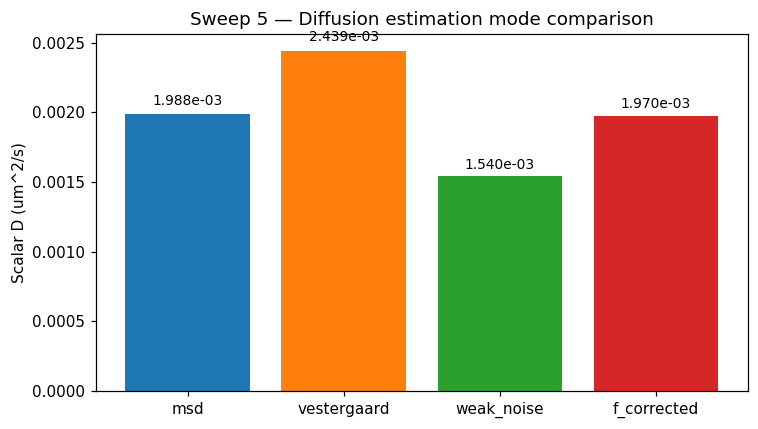

In [15]:
fig_diff, ax_diff = plt.subplots(figsize=(7, 4))
modes_plotted = list(D_scalar_by_mode.keys())
d_values = [D_scalar_by_mode[m] for m in modes_plotted]
x_pos = np.arange(len(modes_plotted))
bars = ax_diff.bar(x_pos, d_values, color=["C0", "C1", "C2", "C3"][: len(modes_plotted)])
ax_diff.set_xticks(x_pos)
ax_diff.set_xticklabels(modes_plotted)
ax_diff.set_ylabel("Scalar D (um^2/s)")
ax_diff.set_title("Sweep 5 — Diffusion estimation mode comparison")
for bar, val in zip(bars, d_values):
    ax_diff.text(
        bar.get_x() + bar.get_width() / 2.0,
        val * 1.02,
        f"{val:.3e}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig_diff.tight_layout()
plt.show()

## Summary

In [16]:
print("=" * 60)
print("Hyperparameter sensitivity summary")
print("=" * 60)
print(f"{'Parameter':<30} {'Best value':<20} {'CV MSE'}")
print("-" * 60)

# Basis size
print(
    f"  {'n_basis':<28} {best_n_basis:<20} "
    f"{cv_basis[str(best_n_basis)].mean_error:.4e}"
)

# Regularisation
print(
    f"  {'lambda_ridge':<28} {best_ridge:<20.2e} "
    f"{min(ridge_means):.4e}"
)
print(
    f"  {'lambda_rough':<28} {best_rough:<20.2e} "
    f"{min(rough_means):.4e}"
)

# Estimator mode
print(
    f"  {'basis_eval_mode':<28} {best_mode:<20} "
    f"{cv_mode[best_mode].mean_error:.4e}"
)

# Endpoint method
if cv_endpoint:
    print(
        f"  {'endpoint_method':<28} {best_endpoint:<20} "
        f"{cv_endpoint[best_endpoint].mean_error:.4e}"
    )
else:
    print(f"  {'endpoint_method':<28} {'N/A (CV failed)':<20}")

# Diffusion mode (no CV — just D values)
if D_scalar_by_mode:
    d_spread = max(D_scalar_by_mode.values()) - min(D_scalar_by_mode.values())
    d_mean = np.mean(list(D_scalar_by_mode.values()))
    print(
        f"  {'diffusion_mode':<28} {'(see D values)':<20} "
        f"spread = {d_spread:.3e} ({100*d_spread/d_mean:.1f}% of mean)"
    )

print("=" * 60)

Hyperparameter sensitivity summary
Parameter                      Best value           CV MSE
------------------------------------------------------------
  n_basis                      4                    7.7350e-04
  lambda_ridge                 1.13e-02             7.7353e-04
  lambda_rough                 1.13e-02             7.7353e-04
  basis_eval_mode              ito_shift            7.7018e-04
  endpoint_method              frac=1.00            7.2911e-04
  diffusion_mode               (see D values)       spread = 8.988e-04 (45.3% of mean)
